In [8]:
import skimage as skim
import sklearn 
import scipy
import cv2
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from tqdm import tqdm
%load_ext autoreload
%autoreload 2
import _utils
import config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Region Growing

### Code necessary for the following explanation

The two cells below are the code explained above and are only here as they are necessary for the following explanations.

In [15]:
feat_ref = []
for name in config.names:
    ref = np.array(Image.open(config.reference_path+'/'+name+'.jpg'))
    annot = np.array(Image.open(config.annotated_path+'/'+name+'_annotated.jpg'), dtype=bool)

    binned = _utils.median_bin_rgb(ref, block_size=(10, 10))
    annot = skim.measure.block_reduce(annot, block_size=(10,10), func=np.median)

    binned_bgr = cv2.cvtColor(binned, cv2.COLOR_RGB2BGR)
    binned_hsv = cv2.cvtColor(binned_bgr, cv2.COLOR_BGR2HSV)

    spx = skim.segmentation.slic(binned, n_segments=5000, compactness=.1, sigma=1, start_label=0)

    hsv_feat = _utils.hsv_spx_feat(binned_hsv, spx, np.median)
    h_ref = binned_hsv[annot>=1][:,0]/180
    s_ref = binned_hsv[annot>=1][:,1]/255
    v_ref = binned_hsv[annot>=1][:,2]/255

    hx_ref = np.cos(h_ref*2*np.pi)
    hy_ref = np.sin(h_ref*2*np.pi)
    
    feat_ref.append(np.array([hx_ref, hy_ref, s_ref, v_ref]).T)

feat_ref = np.vstack(feat_ref)
gmm_ref = sklearn.mixture.GaussianMixture(n_components=1, covariance_type='full', reg_covar=1e-3)
gmm_ref.fit(feat_ref)

GaussianMixture(reg_covar=0.001)

In [26]:
img = np.array(Image.open("../data/dataset_project_iapr2025/train/L1000792.JPG"))
binned = _utils.median_bin_rgb(img, block_size=(10, 10))

binned_hsv = _utils.rgb_to_hsv(binned)

spx = skim.segmentation.slic(binned, n_segments=10000, compactness=.05, sigma=0.1, start_label=0)

hsv_feat = _utils.hsv_spx_feat(binned_hsv, spx, np.median)

gmm = _utils.gmm_on_spx_fit(range(1,10), hsv_feat)
labels = _utils.gmm_on_spx_predict(gmm, hsv_feat[spx], spx)

kl_divergences = np.full(np.max(labels)+1, np.inf)
for i in range(np.max(labels)+1):
    if len(binned_hsv[labels==i]) > 1000 and np.linalg.eigvals(gmm.covariances_[i]).max()<0.7:
        kl_divergences[i] = _utils.symmetric_kl(gmm.means_[i], gmm.covariances_[i], gmm_ref.means_[0], gmm_ref.covariances_[0])

best_label = np.argmin(kl_divergences)
merged = _utils.merge_labels(labels, best_label, 0.25)
binary = merged==best_label

### Functions

A region growing algorithm was implemented to enhance the shape of the chocolates and get a better contours of the chocolate.

In [21]:
def mean_from_mask(img, mask):
    mean = np.mean(img[mask])
    return mean

def offset_range(img, mean, offset):
    img_range = ((img < mean + offset) & (img > mean - offset))
    return img_range

The functions `mean_from_mask` and `offset_range` are two simple functions used by the function `region_growing`:

- `mean_from_mask`: compute the mean value of a pixels of an image according to a mask.
- `offset_range`: compute a mask corresponding to a range of pixels value in an image.

In [36]:
def region_growing(rgb_img, hsv_img, mask):
    mask = skim.morphology.binary_closing(mask, skim.morphology.disk(5))
    mask = skim.morphology.remove_small_holes(mask, area_threshold=200)
    mask = skim.morphology.remove_small_objects(mask, min_size=50)
    mask = mask.astype(np.uint8)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    rg_mask = np.zeros_like(mask)
    rg_mask = rg_mask.astype(bool)

    for contour in contours:

        small_mask = np.zeros_like(mask)

        cv2.drawContours(small_mask, [contour], -1, 255, thickness=cv2.FILLED)

        small_mask = small_mask.astype(bool)

        mean_red = mean_from_mask(rgb_img[:,:,0], small_mask)
        mean_green = mean_from_mask(rgb_img[:,:,1], small_mask)
        mean_blue = mean_from_mask(rgb_img[:,:,2], small_mask)

        mean_hue = mean_from_mask(hsv_img[:,:,0], small_mask)
        mean_sat = mean_from_mask(hsv_img[:,:,1], small_mask)
        mean_val = mean_from_mask(hsv_img[:,:,2], small_mask)

        offset_hue = 80
        offset_sat = 60
        offset_val = 60

        offset_red = 45
        offset_green = 60
        offset_blue = 70
        
        labelled = (offset_range(hsv_img[:,:,0], mean_hue, offset_hue) & offset_range(hsv_img[:,:,1], mean_sat, offset_sat) & offset_range(hsv_img[:,:,2], mean_val, offset_val) &
                    offset_range(rgb_img[:,:,0], mean_red, offset_red) & offset_range(rgb_img[:,:,1], mean_green, offset_green) & offset_range(rgb_img[:,:,2], mean_blue, offset_blue))

        small_mask = skim.morphology.binary_erosion(small_mask, skim.morphology.disk(5))

        n_iterations = 10
        
        for i in range(n_iterations):         
            small_mask |= (skim.morphology.binary_dilation(small_mask, skim.morphology.disk(3)) & labelled)     

        rg_mask |= (small_mask == 1)

    rg_mask = skim.morphology.binary_closing(rg_mask, skim.morphology.disk(5))
    rg_mask = skim.morphology.remove_small_holes(rg_mask, area_threshold=1000)
    rg_mask = skim.morphology.remove_small_objects(rg_mask, min_size=50)
    return rg_mask

The function `region_growing` has three arguments, the image in RGB and in HSV and the mask computed before.

The differents steps performed in this function are:

1. Different skimage morphology functions are applied and the mask to remove small defects.
2. The contours are extracted from the mask. The region growing will be performed on one contour at a time.
3. For each contours:
    - A mask is created from the contour.
    - The mean value of the RBG and HSV channels are computed using the `mean_from_mask`function and the different acceptable offsets per channel are initialised.
    - The labelled variable is computed as the mask that is true for all the range computed according to the different channels and offsets.
    - The region growing is performed on 10 iterations. Before the region growing, an erosion is performed on the mask, it was observed that this erosion helped to get a more smooth final shape.
    - the region grown mask is added the new mask.
4. Different skimage morphology functions are applied and the new mask to remove small defects.

This function performs a region growing algorithm per detected chocolate, the intent is to get a more finetuned region growing as the mean are computed per detected region on not on the entire mask.



### Results

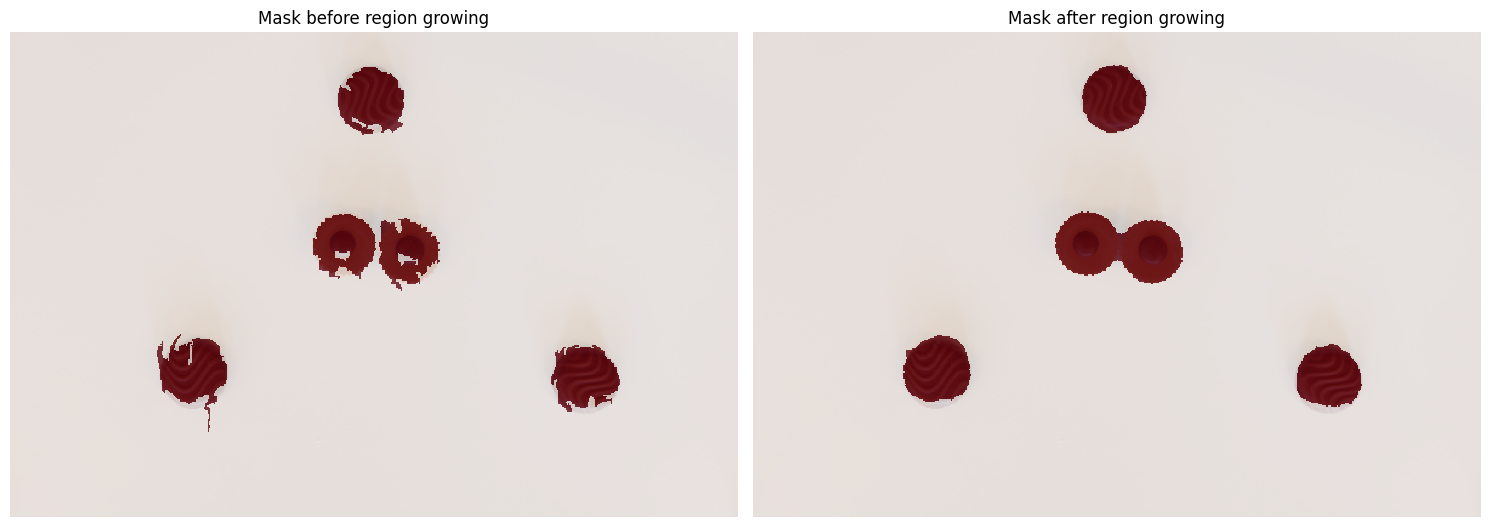

In [38]:
rg_mask = region_growing(binned, binned_hsv, binary)

fig, ax = plt.subplots(1, 2, figsize=(15, 10))

ax[0].imshow(binned)
ax[0].imshow(binary, alpha=0.7, cmap='Reds', interpolation='none')
ax[0].set_title('Mask before region growing')
ax[0].axis('off')

ax[1].imshow(binned)
ax[1].imshow(rg_mask, alpha=0.7, cmap='Reds', interpolation='none')
ax[1].set_title('Mask after region growing')
ax[1].axis('off')

plt.tight_layout()
plt.show()

Results from the region growing algorithm is shown above on an example, the mask is more refined and smooth after the region growing algorithm.

The region growing produce a unique final mask for all the chocolate, the separation of the different chocolates in different masks will be done in another function.

### Parameters finetuning

In [ ]:
reference_data_path = '../data/dataset_project_iapr2025/references'
reference_mask_data_path = '../data/dataset_project_iapr2025/references_annotated'

list_channel = ['red', 'green', 'blue', 'hue', 'saturation', 'value']
list_chocolate = ['Amandina', 'Arabia', 'Comtesse', 'Creme_brulee', 'Jelly_Black', 'Jelly_Milk', 'Jelly_White', 'Noblesse', 'Noir_authentique',
        'Passion_au_lait', 'Stracciatella', 'Tentation_noir', 'Triangolo']

std = np.zeros((len(list_channel), len(list_chocolate), 4))

for i, filename in enumerate(tqdm(os.listdir(reference_data_path))):
    full_path = os.path.join(reference_data_path, filename)
    if os.path.isfile(full_path):
        rgb_img = np.array(Image.open(full_path))
        hsv_img = _utils.rgb_to_hsv(rgb_img)

        name, _ = os.path.splitext(filename)
        mask_filename = name + '_annotated.jpg'
        mask_path = os.path.join(reference_mask_data_path, mask_filename)
        mask = np.array(Image.open(mask_path)).

        rgb_binned = _utils.median_bin_rgb(rgb_img, block_size=(10, 10))
        hsv_binned = _utils.median_bin_rgb(hsv_img, block_size=(10, 10))
        mask = skim.measure.block_reduce(mask, block_size=(10,10), func=np.median)
        mask = mask.astype(bool)

        rgb_pixels = rgb_binned[mask]
        hsv_pixels = hsv_binned[mask]

        for j in range(3):
            mu_rgb, std_rgb = scipy.stats.norm.fit(rgb_pixels[:,j])
            mu_hsv, std_hsv = scipy.stats.norm.fit(hsv_pixels[:,j])             
            std[j,i] = mu_rgb, std_rgb, min(rgb_pixels[:,j]), max(rgb_pixels[:,j])
            std[j+3,i] = mu_hsv, std_hsv, min(hsv_pixels[:,j]), max(hsv_pixels[:,j])       

100%|██████████| 13/13 [00:46<00:00,  3.58s/it]


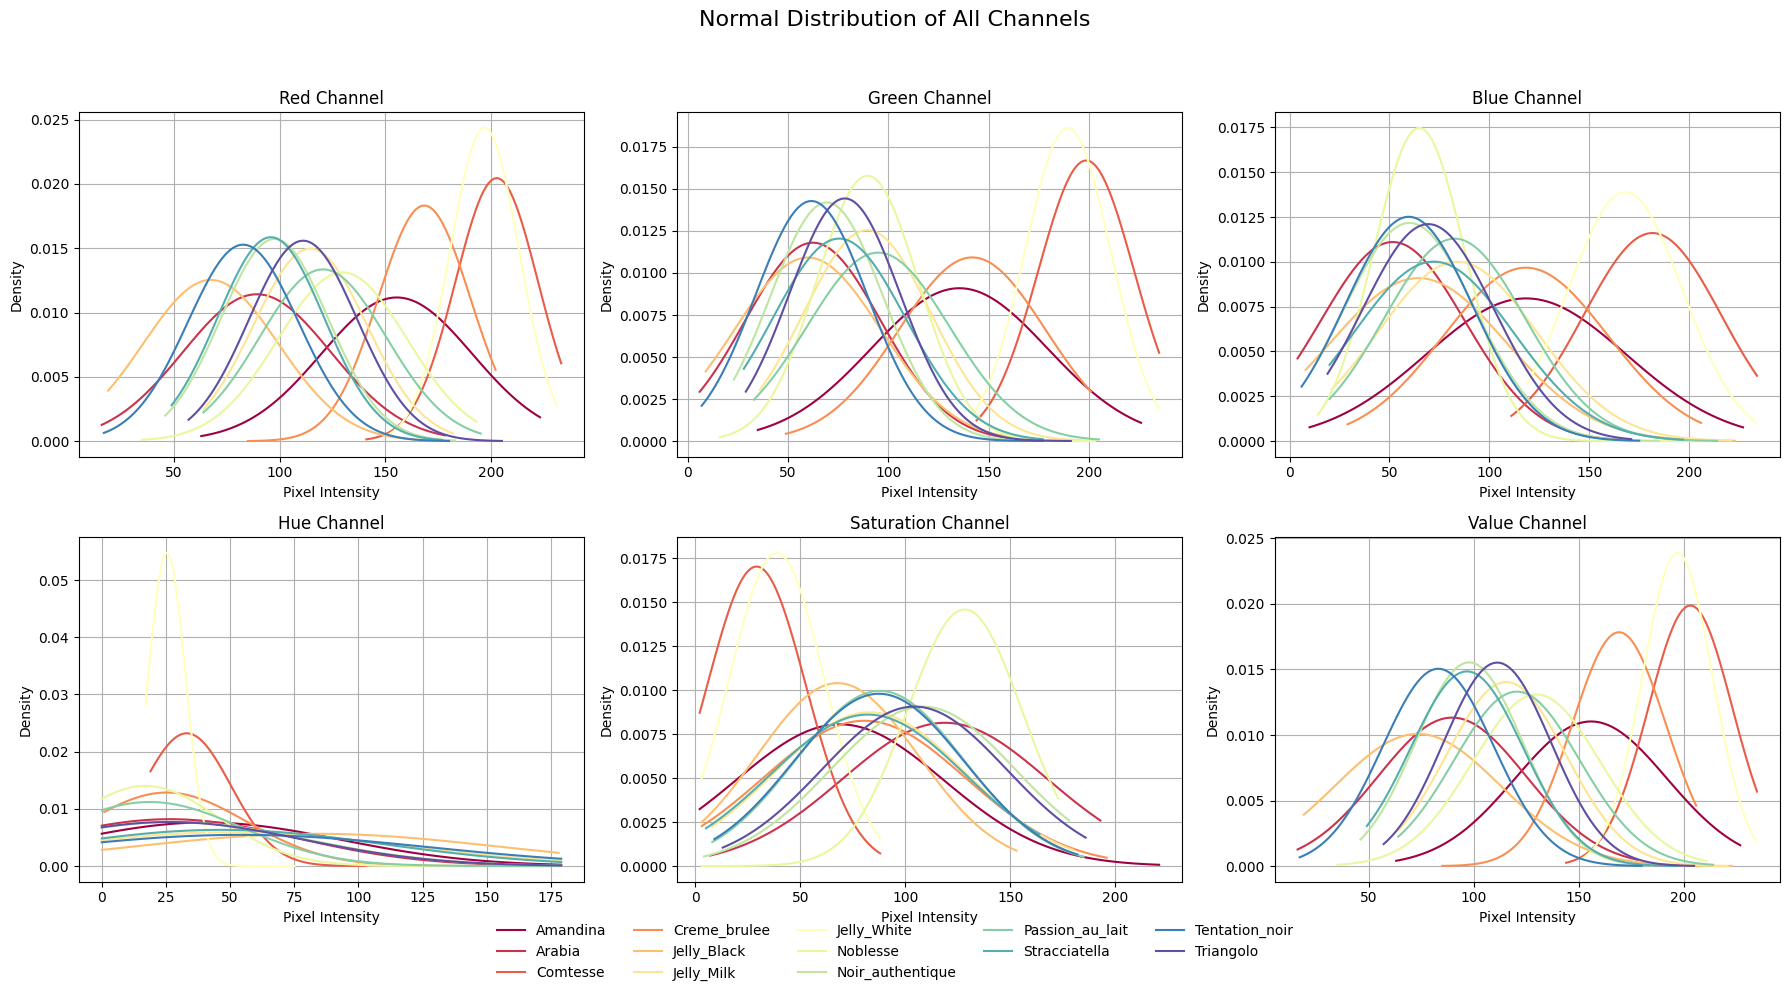

In [121]:
colors = cm.Spectral(np.linspace(0, 1, len(list_chocolate)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(len(list_channel)):
    ax = axes[i]
    for j in range(len(list_chocolate)):
        mu, std_dev, xmin, xmax = std[i][j]
        x = np.linspace(xmin, xmax, 100)
        pdf = scipy.stats.norm.pdf(x, mu, std_dev)
        ax.plot(x, pdf, color=colors[j], linewidth=1.5, label=list_chocolate[j])

    ax.set_title(f'{list_channel[i].capitalize()} Channel')
    ax.set_xlabel('Pixel Intensity')
    ax.set_ylabel('Density')
    ax.grid(True)

fig.legend(list_chocolate, loc='lower center', ncol=5, fontsize=10, frameon=False)
fig.suptitle('Normal Distribution of All Channels', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

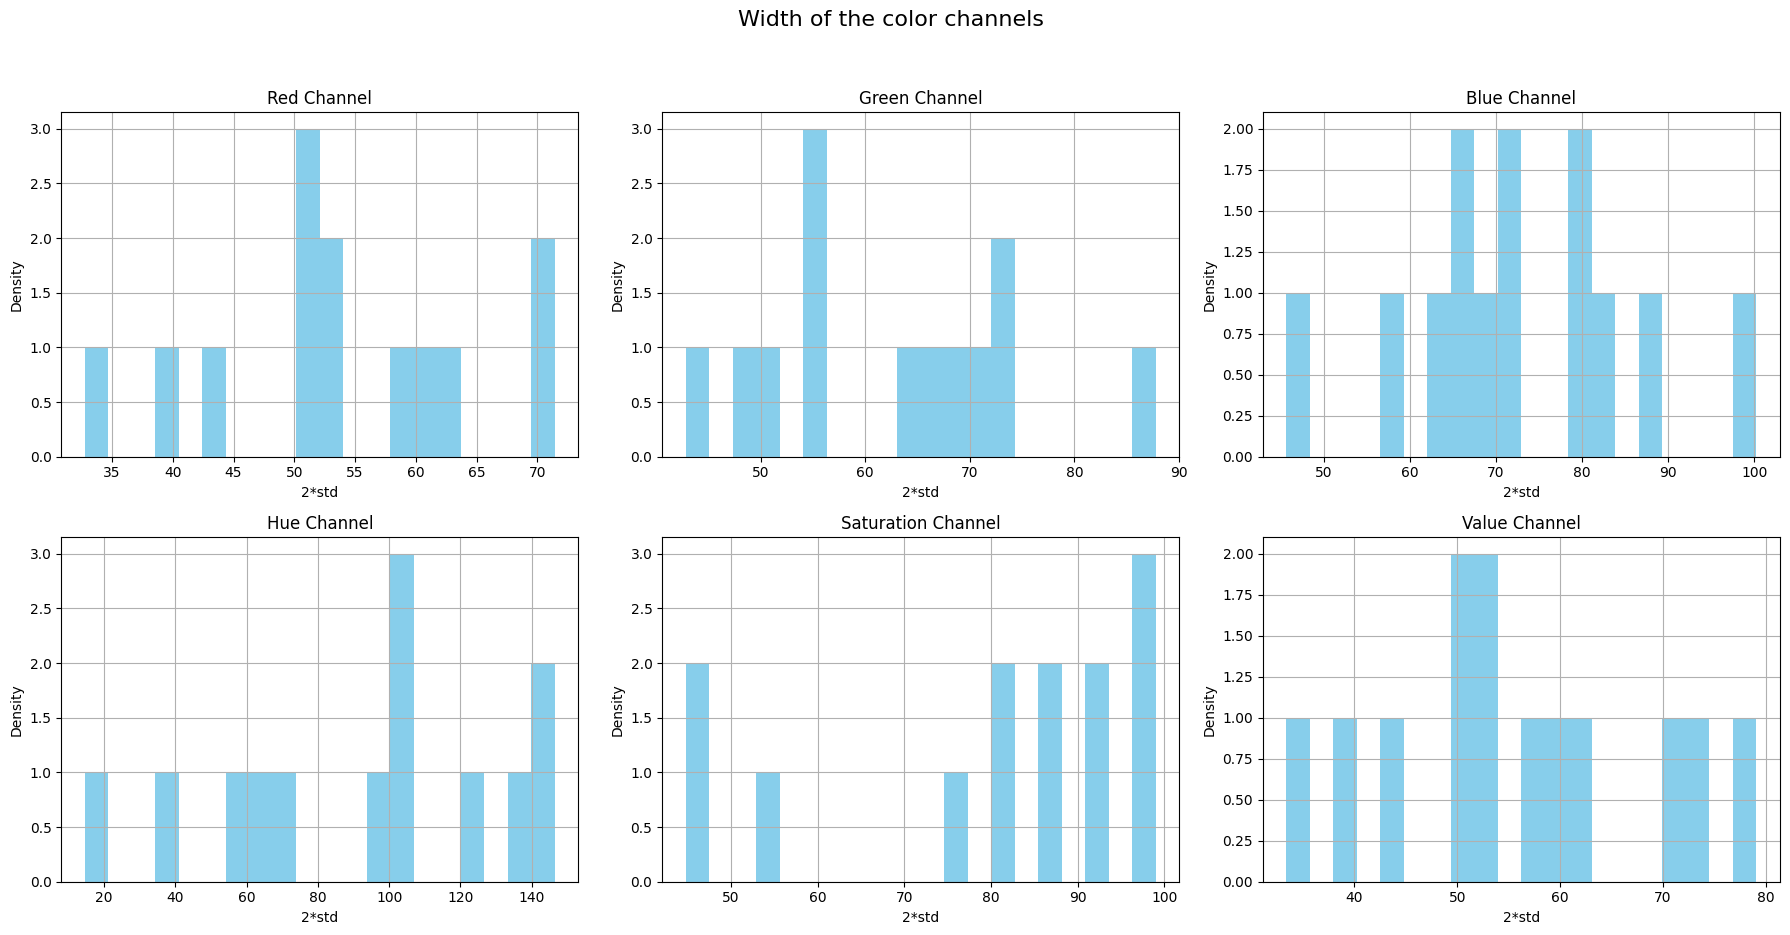

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(len(list_channel)):
    ax = axes[i]
    ranges = np.zeros((len(list_chocolate)))
    for j in range(len(list_chocolate)):
        ranges[j] = 2*std[i][j][1]
    
    ax.hist(ranges, bins=20, color='skyblue')
    ax.set_title(f'{list_channel[i].capitalize()} Channel')
    ax.set_xlabel('2*std')
    ax.set_ylabel('Density')
    ax.grid(True)

fig.suptitle('Width of the color channels ', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


### Parameters Justification for Watershed

In [111]:
reference_data_path = '../data/dataset_project_iapr2025/references'
reference_mask_data_path = '../data/dataset_project_iapr2025/references_annotated'

chocolate_number = 13

sizes_distribution = np.zeros((chocolate_number))

for i, filename in enumerate(tqdm(os.listdir(reference_data_path))):
    full_path = os.path.join(reference_data_path, filename)
    if os.path.isfile(full_path):

        name, _ = os.path.splitext(filename)
        mask_filename = name + '_annotated.tif'
        mask_path = os.path.join(reference_mask_data_path, mask_filename)
        mask = np.array(Image.open(mask_path))

        mask = skim.measure.block_reduce(mask, block_size=(10,10), func=np.median)
        mask = mask.astype(bool)

        sizes_distribution[i] = np.count_nonzero(mask)


100%|██████████| 13/13 [00:03<00:00,  4.22it/s]


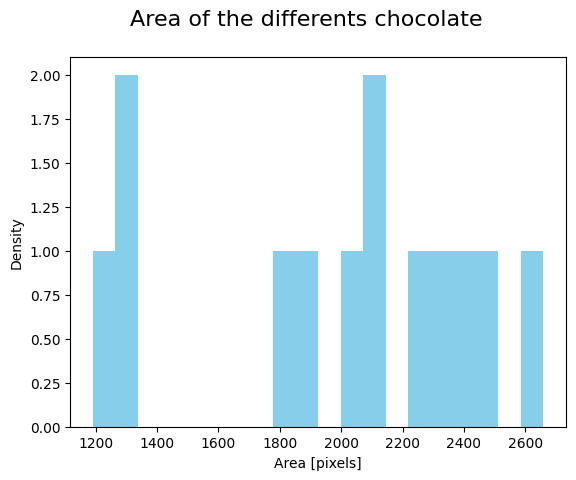

In [123]:
plt.hist(sizes_distribution, bins=20, color='skyblue')
plt.xlabel('Area [pixels]')
plt.ylabel('Density')
plt.suptitle('Area of the differents chocolate ', fontsize=16)
plt.show()